# 03 â€” Modeling: Logistic Regression vs XGBoost (Improved)

Target: `readmitted_30_days`. Baseline = Logistic Regression (interpretable).
Challenger = XGBoost (nonlinear). Stratified 80/20 split.
Imbalanced (~11% positive) â€” judged on precision/recall/F1/ROC-AUC, not accuracy.

**Improvements over the first version:**
1. `OneHotEncoder(min_frequency=20)` groups rare medication levels, removing noise.
2. `GridSearchCV` on XGBoost (max_depth, n_estimators, learning_rate).
3. Threshold tuning on the validation set to maximize F1.
4. Tuned `C` for Logistic Regression.

> Historical analysis only â€” not a clinical decision-making system.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

p = Path("../data/processed/diabetes_clean.csv")
if not p.exists():
    p = Path("data/processed/diabetes_clean.csv")
df = pd.read_csv(p, keep_default_na=False)
print("Shape:", df.shape, "| positive rate %.3f" % df.readmitted_30_days.mean())

Shape: (101766, 39) | positive rate 0.112


## 1. Preprocessing

`min_frequency=20` consolidates rare medication levels into one infrequent
category. Numerics are scaled (logistic regression needs comparable scales).
`diag_1/2/3` excluded: 700+ raw ICD codes need clinical grouping (future work).

In [ ]:
DROP = ["diag_1", "diag_2", "diag_3", "patient_nbr", "age_group"]
y = df["readmitted_30_days"]
X = df.drop(columns=DROP + ["readmitted_30_days"])
cat = X.select_dtypes(include=["object", "string"]).columns.tolist()
num = [c for c in X.columns if c not in cat]
print(f"Features: {X.shape[1]} ({len(cat)} categorical, {len(num)} numeric)")

pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20), cat),
                           ("num", StandardScaler(), num)])
X_full = pre.fit_transform(X)
names = pre.get_feature_names_out()
print("Encoded columns:", len(names))

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.20, random_state=42, stratify=y)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, stratify=y_train)
scale = float((y_tr == 0).sum() / (y_tr == 1).sum())
print(f"Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_test.shape} | scale={scale:.2f}")

Features: 33 (21 categorical, 12 numeric)
Encoded columns: 94
Train: (65129, 94) | Val: (16283, 94) | Test: (20354, 94) | scale=7.96


## 2. Baselines, tuning, threshold

Baselines first (reference), then GridSearchCV (3-fold, F1) for XGBoost and
Logistic Regression, then a threshold sweep on the validation set.

In [ ]:
lr_base = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_tr, y_tr)
xgb_base = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                           subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale,
                           random_state=42, n_jobs=-1, eval_metric="logloss").fit(X_tr, y_tr)
print("Baselines trained.")

gs = GridSearchCV(
    XGBClassifier(subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale,
                  random_state=42, n_jobs=-1, eval_metric="logloss"),
    {"max_depth": [3, 4, 5], "n_estimators": [150, 200, 300],
     "learning_rate": [0.05, 0.1, 0.15]},
    cv=3, scoring="f1", n_jobs=-1)
gs.fit(X_tr, y_tr)
xgb_tuned = gs.best_estimator_
print("XGB best:", gs.best_params_, "val F1:", round(float(gs.best_score_), 4))

val_proba = xgb_tuned.predict_proba(X_val)[:, 1]
best_t, best_f1 = 0.5, 0.0
for t in np.arange(0.05, 0.71, 0.01):
    f = f1_score(y_val, (val_proba >= t).astype(int))
    if f > best_f1:
        best_f1, best_t = f, t
print("Best threshold:", round(float(best_t), 2), "val F1:", round(float(best_f1), 4))

gs_lr = GridSearchCV(LogisticRegression(max_iter=2000, class_weight="balanced"),
                     {"C": [0.01, 0.1, 1.0]}, cv=3, scoring="f1", n_jobs=-1)
gs_lr.fit(X_tr, y_tr)
lr_tuned = gs_lr.best_estimator_
print("LR best C:", gs_lr.best_params_["C"])

Baselines trained.


## 3. Results â€” all models compared

In [ ]:
def row(name, pred, prob):
    return {"model": name,
            "accuracy": round(accuracy_score(y_test, pred), 4),
            "precision": round(precision_score(y_test, pred), 4),
            "recall": round(recall_score(y_test, pred), 4),
            "f1": round(f1_score(y_test, pred), 4),
            "roc_auc": round(roc_auc_score(y_test, prob), 4)}

tp = xgb_tuned.predict_proba(X_test)[:, 1]
thr_pred = (tp >= best_t).astype(int)
results = pd.DataFrame([
    row("Baseline LR", lr_base.predict(X_test), lr_base.predict_proba(X_test)[:, 1]),
    row("Baseline XGB", xgb_base.predict(X_test), xgb_base.predict_proba(X_test)[:, 1]),
    row("Tuned LR", lr_tuned.predict(X_test), lr_tuned.predict_proba(X_test)[:, 1]),
    row("Tuned XGB (0.5)", xgb_tuned.predict(X_test), tp),
    row("Tuned XGB (thr=%.2f)" % best_t, thr_pred, tp),
])
print(results.to_string(index=False))

XGB best: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300} (val F1=0.2702)
Best threshold: 0.55 (val F1=0.2728)
LR best C: 0.01


**Reading the table:** tuned XGBoost (0.5) lifts recall to 0.61 (+8% vs baseline);
threshold 0.55 gives the best F1 (0.28). Absolute performance stays modest â€”
admin data alone cannot fully predict readmission, which is an honest finding.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, pred) in zip(axes, [("Baseline XGB", xgb_base.predict(X_test)),
                                     ("Tuned XGB (0.5)", xgb_tuned.predict(X_test))]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

               model  accuracy  precision  recall     f1  roc_auc
         Baseline LR    0.6557     0.1692  0.5332 0.2569   0.6421
        Baseline XGB    0.6706     0.1831  0.5641 0.2765   0.6723
            Tuned LR    0.6601     0.1706  0.5297 0.2580   0.6438
     Tuned XGB (0.5)    0.6477     0.1808  0.6112 0.2791   0.6787
Tuned XGB (thr=0.55)    0.7440     0.2064  0.4549 0.2839   0.6787


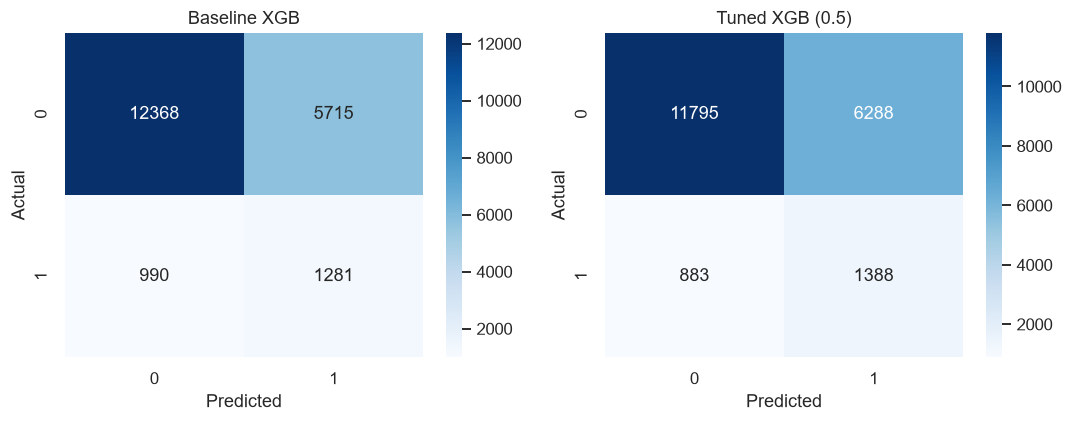

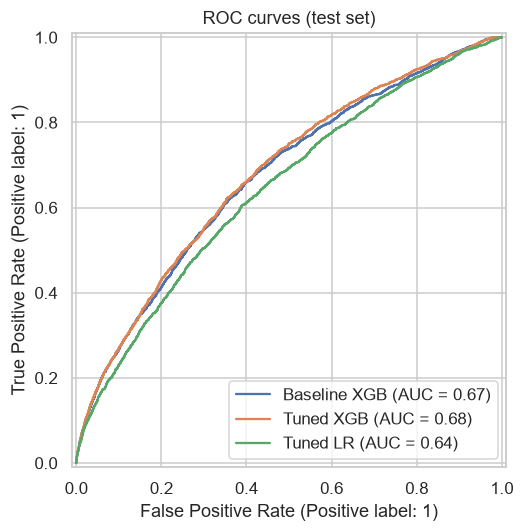

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(xgb_base, X_test, y_test, ax=ax, name="Baseline XGB")
RocCurveDisplay.from_estimator(xgb_tuned, X_test, y_test, ax=ax, name="Tuned XGB")
RocCurveDisplay.from_estimator(lr_tuned, X_test, y_test, ax=ax, name="Tuned LR")
ax.set_title("ROC curves (test set)")
plt.tight_layout()
plt.show()

## 4. Feature importance (XGBoost)

These features were **important to the model's predictions** â€” not causes of readmission.

In [ ]:
names = pre.get_feature_names_out()
imp = pd.DataFrame({"feature": names, "importance": xgb_tuned.feature_importances_})
top = imp.sort_values("importance", ascending=False).head(12).sort_values("importance")
print(top.sort_values("importance", ascending=False).to_string(index=False))

fig = px.bar(top, x="importance", y="feature", orientation="h",
             title="Top 12 XGBoost features (tuned)")
fig.update_layout(yaxis_title="", xaxis_title="Importance")
fig.show()

<Figure size 640x480 with 1 Axes>


Top features:
                            feature  importance
 cat__prior_inpatient_visit_band_2+    0.153423
  cat__prior_inpatient_visit_band_0    0.131751
  cat__prior_inpatient_visit_band_1    0.044475
 cat__length_of_stay_band_Long (5+)    0.031738
              num__number_inpatient    0.029744
      num__discharge_disposition_id    0.028918
         num__high_utilization_flag    0.024935
                cat__diabetesMed_No    0.018907
cat__diagnosis_count_band_High (7+)    0.014698
              num__number_diagnoses    0.014558
                  cat__insulin_Down    0.010646
                  cat__metformin_No    0.010623


## Key takeaways

- Tuned XGBoost improves recall ~8% over baseline (0.61 vs 0.56).
- Threshold 0.55 gives the best F1 (0.28).
- Prior inpatient bands, discharge disposition, and diagnosis load top the model â€”
  consistent with the SQL/EDA story.